## Finding Duplicated and Similar Images With Hashing

Um dos principais problemas em busca de imagens é encontrar imagens duplicadas e buscar imagens semelhantes

- Ao treinar um modelo saber se na base de dadps há imagens duplicadas é util pois podemos remover redundancias

- 

In [ ]:
import os
from pathlib import Path

# Função para detectar a raiz do projeto com base na presença de ".venv"
def find_project_root(max_depth=10):
    current = Path.cwd()
    for i in range(max_depth):
        if any((current / name).exists() for name in [".venv", "pyproject.toml", ".git"]):
            print(f"📁 Raiz do projeto encontrada: {current}")
            os.chdir(current)
            return current
        print(f"{i} - Subindo para: {current.parent}")
        current = current.parent
    raise RuntimeError("❌ Raiz do projeto não encontrada.")

# Executa a busca
project_root = find_project_root()

# Ativa autoreload para desenvolvimento dinâmico
%load_ext autoreload
%autoreload 2

0 - Descendo  para: g:\py_projects\computer-vision\pos_visão_computacional
1 - Descendo  para: g:\py_projects\computer-vision
📁 Raiz do projeto encontrada: g:\py_projects\computer-vision


In [3]:
import hashlib, os
from glob import glob
import matplotlib.pylab as plt
from skimage.io import imread
from time import time



In [18]:
hex_digest = hashlib.md5(open("data\images\images_com_diferenças\imagens_7_erros\original.png", "rb").read()).hexdigest()
bin_digest = format(int(str(hex_digest), 16), "040b")



hex_digest_mod = hashlib.md5(open("data\images\images_com_diferenças\imagens_7_erros\modificada.png", "rb").read()).hexdigest()
bin_digest_mod = format(int(str(hex_digest_mod), 16), "040b")


<>:1: SyntaxWarning: invalid escape sequence '\i'
<>:6: SyntaxWarning: invalid escape sequence '\i'
<>:1: SyntaxWarning: invalid escape sequence '\i'
<>:6: SyntaxWarning: invalid escape sequence '\i'
C:\Users\guilh\AppData\Local\Temp\ipykernel_25012\2200727968.py:1: SyntaxWarning: invalid escape sequence '\i'
  hex_digest = hashlib.md5(open("data\images\images_com_diferenças\imagens_7_erros\original.png", "rb").read()).hexdigest()
C:\Users\guilh\AppData\Local\Temp\ipykernel_25012\2200727968.py:6: SyntaxWarning: invalid escape sequence '\i'
  hex_digest_mod = hashlib.md5(open("data\images\images_com_diferenças\imagens_7_erros\modificada.png", "rb").read()).hexdigest()


In [19]:
print(f"MD5 digest = {hex_digest} ({bin_digest})")
print(f"Length of hex digest = {len(hex_digest)} bytes")
print(f"Length of bin digest = {len(bin_digest)} bits")

MD5 digest = cc4e1a941232718f75286f4d8a2237a0 (11001100010011100001101010010100000100100011001001110001100011110111010100101000011011110100110110001010001000100011011110100000)
Length of hex digest = 32 bytes
Length of bin digest = 128 bits


In [40]:
from skimage.data import file_hash


def find_duplicates(dir_name):
    def is_image(file_name):
        file = file_name.lower()
        return file.endswith(".png") or file.endswith("jpg")
    
    hash_keys = dict()
    for file_name in glob(dir_name):
        print(file_name)
        if os.path.isfile(file_name) and is_image(file_name):
            with open(file_name, "rb") as file:
                hex_digest = hashlib.md5(file.read()).hexdigest()
                if hex_digest not in hash_keys:
                    hash_keys[hex_digest] = [file_name]
                else:
                    hash_keys[hex_digest].append(file_name)
    
    return [hash_keys[file_hash] for file_hash in hash_keys if len(hash_keys[file_hash]) > 1] 



def show_duplicates(duplicates):
    for duplicated in duplicates:
        try:
            plt.figure(figsize=(20,10))
            plt.subplots_adjust(0,0,1,0.9,0.05,0.05)
            for (i, file_name) in enumerate(duplicated):
                plt.subplot(1, len(duplicated), i+1)
                plt.imshow(plt.imread(file_name))
                plt.title(file_name, size=20)

            plt.axis("off")
            plt.suptitle(f"{len(duplicated)} duplicate images found with MD5 hash", size=30)
            plt.show()

        except OSError as e:
            continue

duplicates = find_duplicates("data/images/imagens_duplicadas/*.*")

data/images/imagens_duplicadas\beija-flor.jpg
data/images/imagens_duplicadas\cafe.jpg
data/images/imagens_duplicadas\casa.jpg
data/images/imagens_duplicadas\Case 1.png
data/images/imagens_duplicadas\cavalo.jpg
data/images/imagens_duplicadas\estrada.jpg
data/images/imagens_duplicadas\eu.jpeg
data/images/imagens_duplicadas\image copy 2.png
data/images/imagens_duplicadas\image copy.png
data/images/imagens_duplicadas\image.png
data/images/imagens_duplicadas\image01.jpg
data/images/imagens_duplicadas\image02.jpg
data/images/imagens_duplicadas\image03 copy 2.jpg
data/images/imagens_duplicadas\image03 copy.jpg
data/images/imagens_duplicadas\image03.jpg
data/images/imagens_duplicadas\image1 copy 2.png
data/images/imagens_duplicadas\image1 copy 3.png
data/images/imagens_duplicadas\image1 copy.png
data/images/imagens_duplicadas\image1.png
data/images/imagens_duplicadas\image2.png
data/images/imagens_duplicadas\image3.png
data/images/imagens_duplicadas\image4 copy 2.png
data/images/imagens_duplic

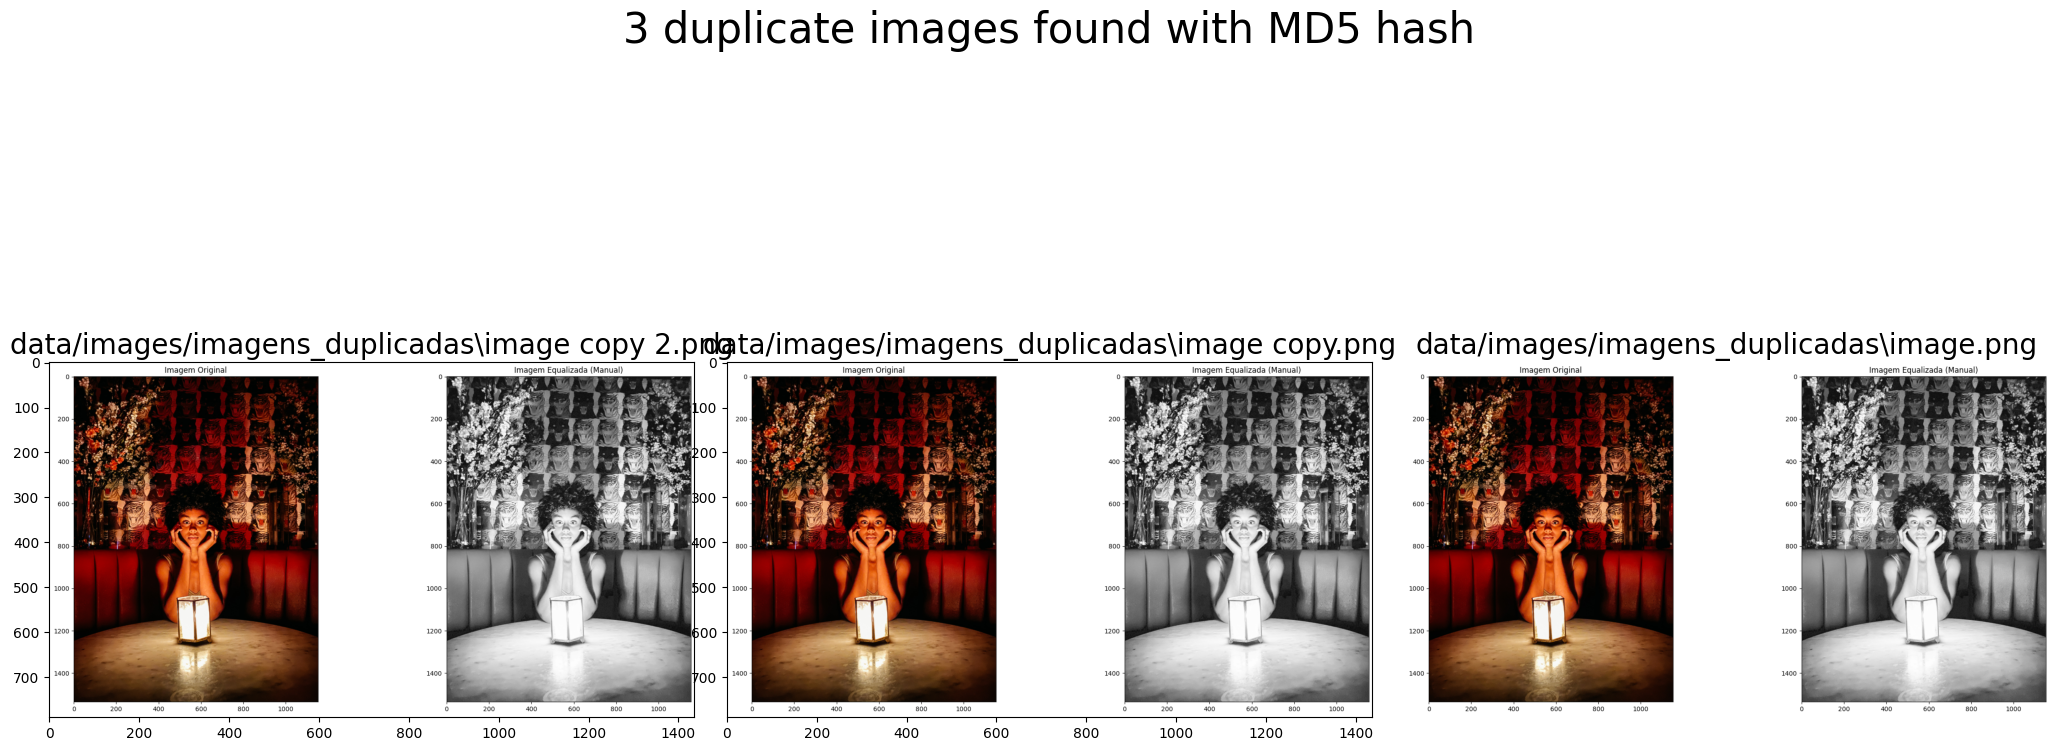

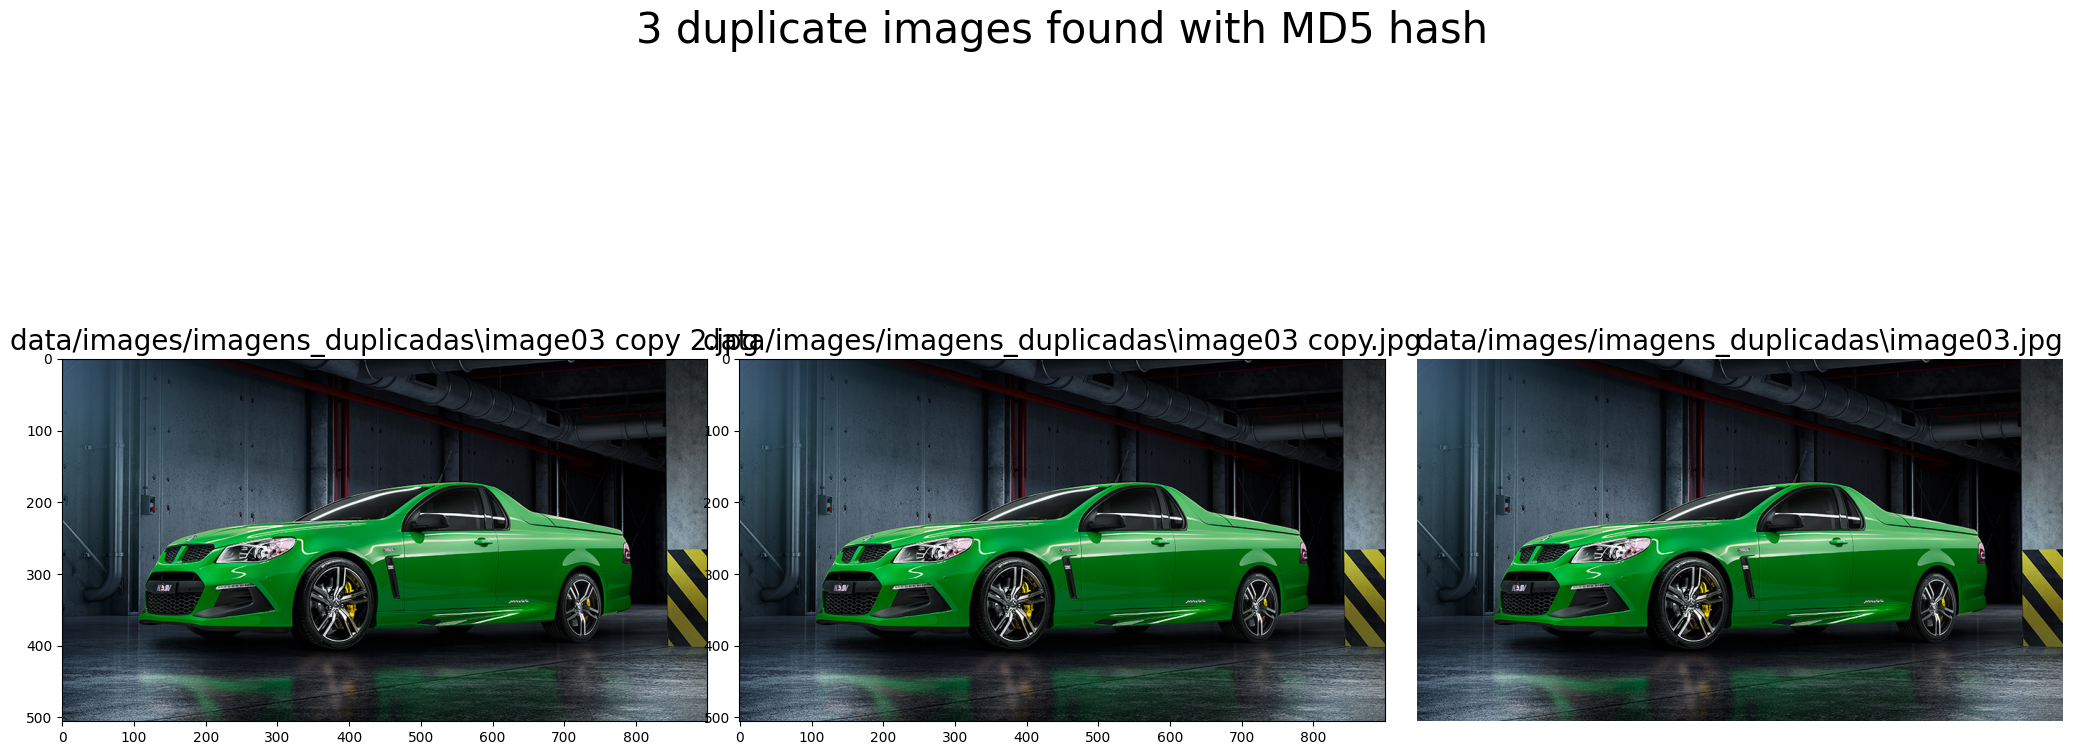

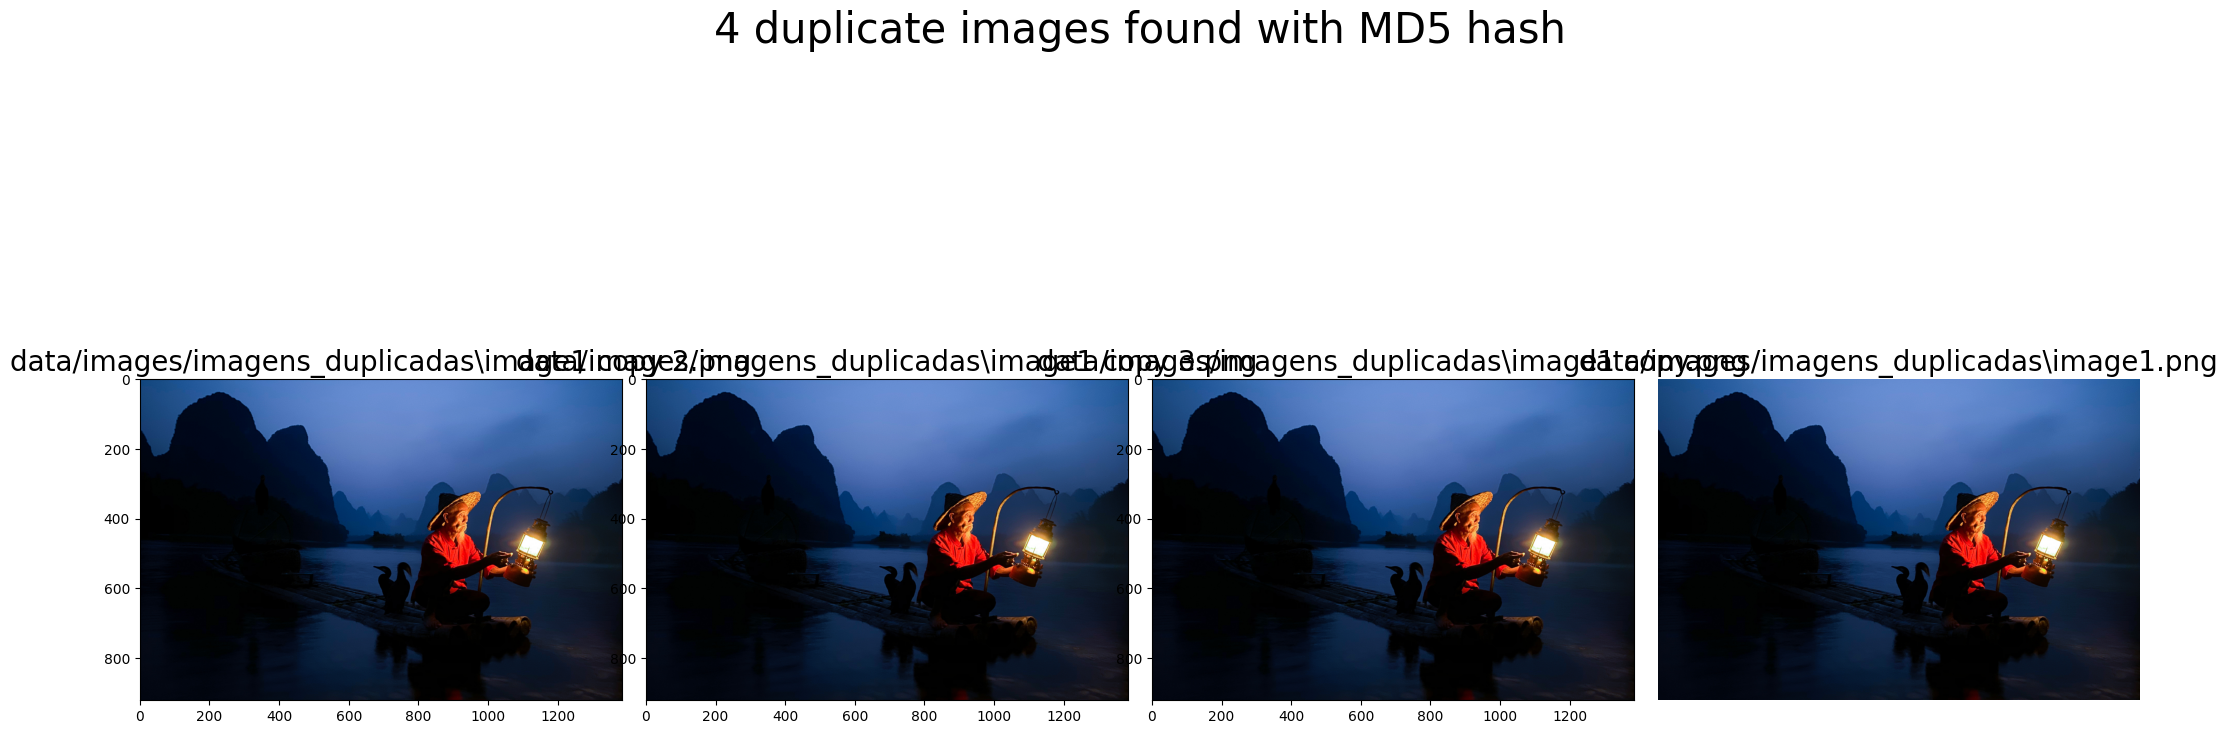

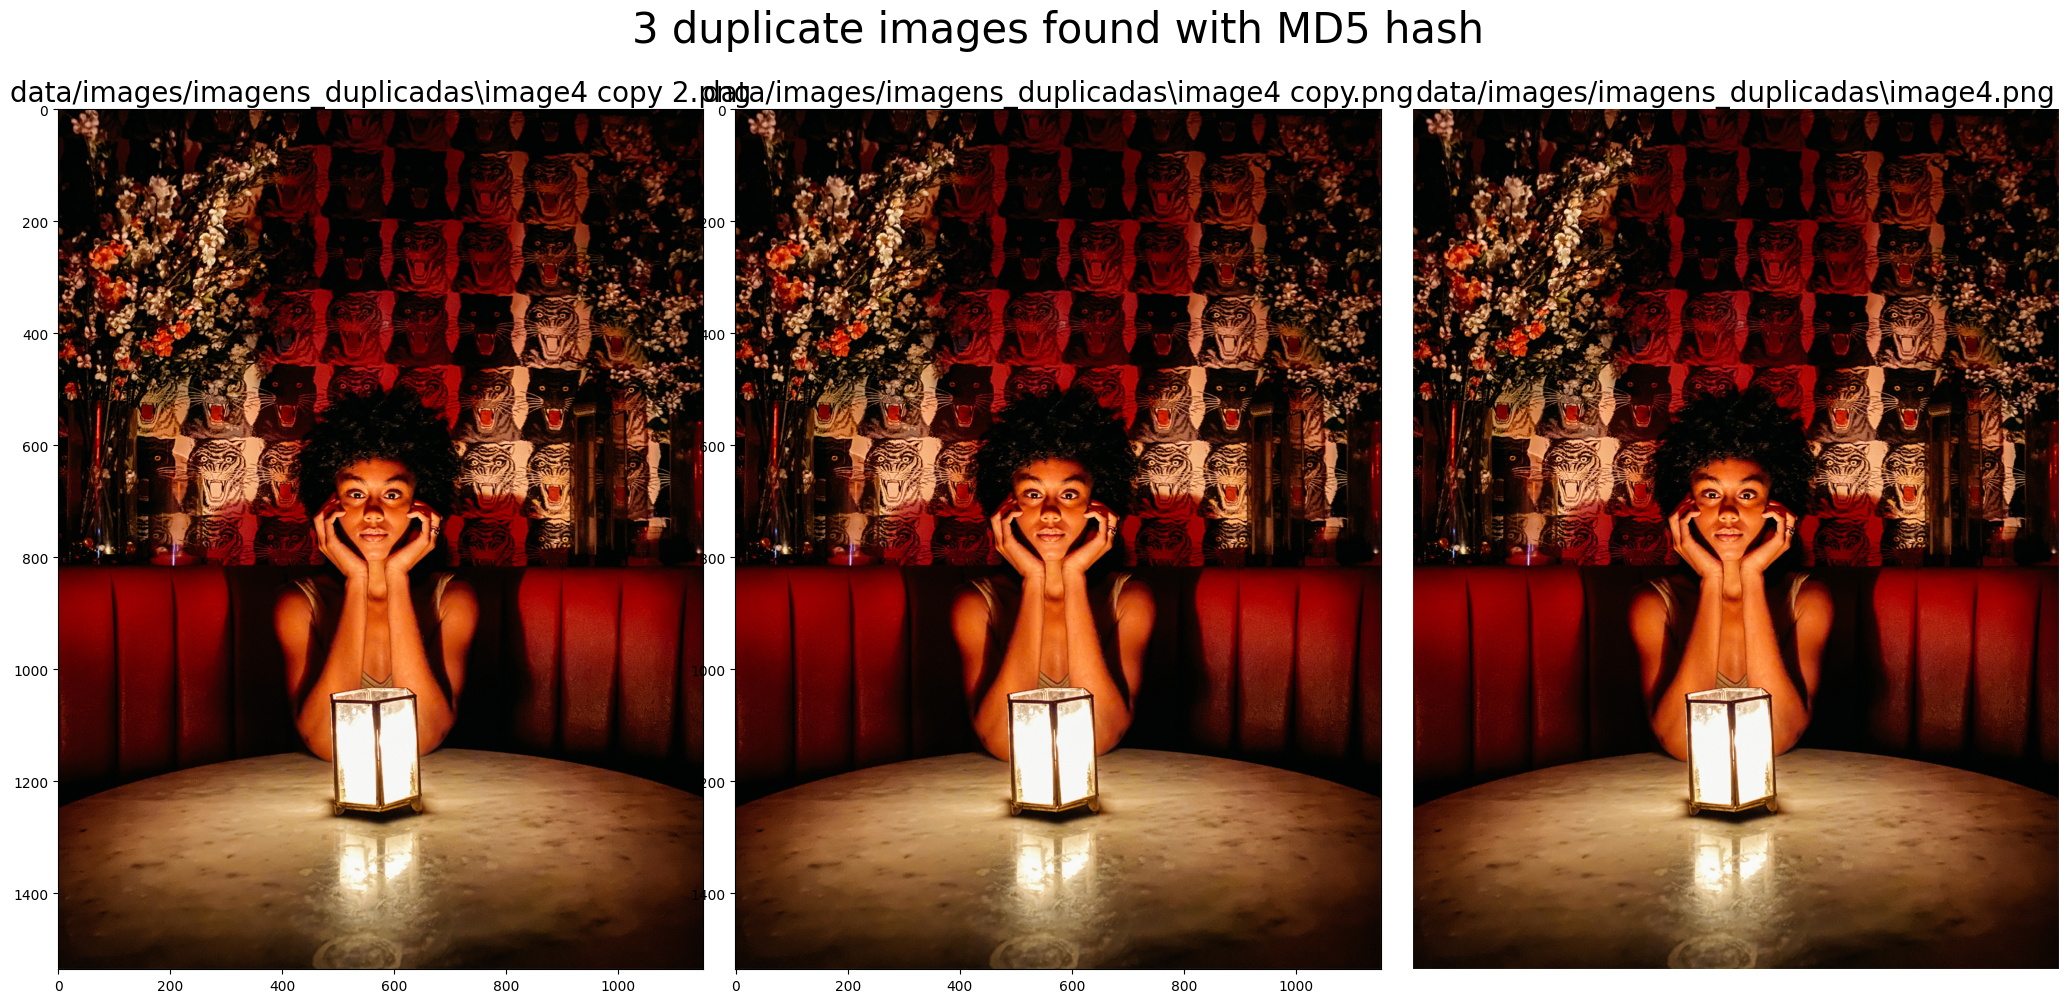

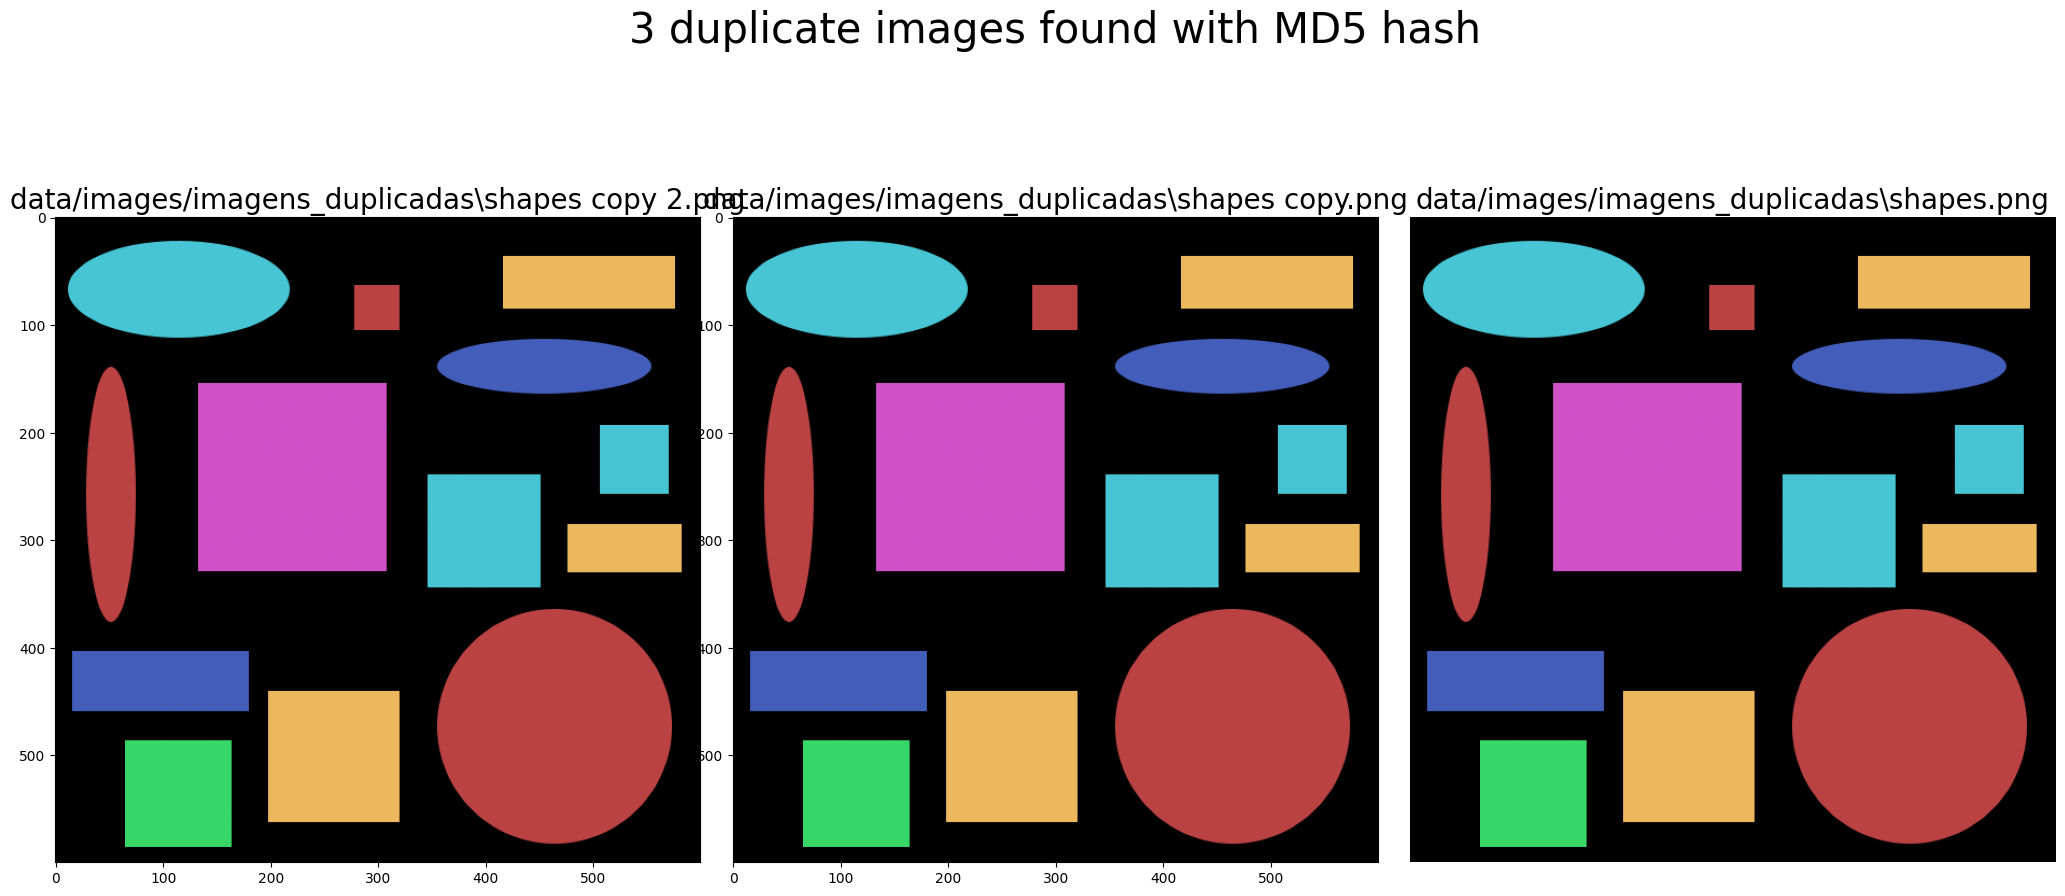

In [41]:
show_duplicates(duplicates)

In [24]:
!dir

 O volume na unidade G � Armazenamento
 O N�mero de S�rie do Volume � 2091-BE76

 Pasta de g:\py_projects\computer-vision

01/08/2025  11:43    <DIR>          .
27/07/2025  11:13    <DIR>          ..
27/07/2025  11:16             3.690 .gitignore
27/07/2025  11:21    <DIR>          .venv
27/07/2025  11:16         2.198.329 Aula pos.ipynb
27/07/2025  11:16           171.615 Case 1 copy.png
27/07/2025  11:16           171.615 Case 1.png
27/07/2025  11:16    <DIR>          data
27/07/2025  11:16    <DIR>          dsa_computer_vision
01/08/2025  08:08            29.030 Economias.ipynb
27/07/2025  11:16    <DIR>          leetcode
01/08/2025  15:35    <DIR>          libs
27/07/2025  11:16    <DIR>          notekooks
02/08/2025  10:21    <DIR>          pos_visao_computacional
01/08/2025  11:43               299 readme.MD
02/08/2025  10:50               110 requirements.txt
27/07/2025  11:16    <DIR>          web_screaping
               7 arquivo(s)      2.574.688 bytes
              10 pasta